<div align="center">
    <img src="recursos/img/logoitqv1.jpg" width="200">
</div>

0.1 01PAO26-26 -Variables cuantitativas

<p align="center">
  <img src="recursos/img/python_logo.png" width="200">
</p>

**Nombre:** Kerly Pilco

**Fecha:** 14/07/2026
**Repositorio:** [Link del repositorio de GitHub]
(https://github.com/kelapilco/machine-1-2026-nocturno.git)

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
-28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)


[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [3]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda , _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [4]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt
Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC
print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


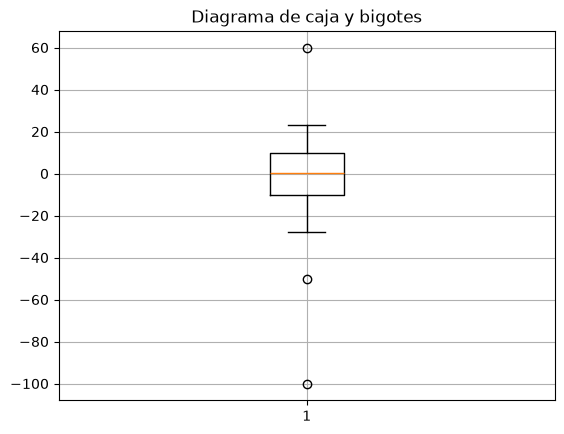

In [5]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de␣outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()


In [6]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [7]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))
if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
   print('Distribución Mesocúrtica')


Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [9]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
pprint(iris)
X = iris.data
y = iris.target
# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
#La variable longitud del pétalo presenta una asimetría positiva leve,
#ya que su coeficiente de asimetría es aproximadamente 0.315, indicando 
#una ligera inclinación hacia la derecha.

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según␣su curtosis?
#???
#La variable ancho del sépalo presenta una distribución leptocúrtica, ya que su curtosis 
#es aproximadamente 0.228, indicando un pico ligeramente más pronunciado que una distribución
#normal.

{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [11]:
import pandas as pd
from sklearn import datasets

In [12]:
# Cargar el conjunto de datos Iris
iris = datasets.load_iris()

# Crear el DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Mostrar las primeras filas
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [13]:
# Asimetría
asimetria = df['petal length (cm)'].skew()

if asimetria > 0:
    print("La longitud del pétalo tiene asimetría positiva.")
elif asimetria < 0:
    print("La longitud del pétalo tiene asimetría negativa.")
else:
    print("La longitud del pétalo es simétrica.")

# Curtosis
curtosis = df['sepal width (cm)'].kurt()

if curtosis > 0:
    print("El ancho del sépalo tiene una distribución leptocúrtica.")
elif curtosis < 0:
    print("El ancho del sépalo tiene una distribución platicúrtica.")
else:
    print("El ancho del sépalo tiene una distribución mesocúrtica.")

La longitud del pétalo tiene asimetría negativa.
El ancho del sépalo tiene una distribución leptocúrtica.


In [14]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la␣clase y representarlo en un gráfico (plt.errorbar)


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

# Cargar el dataset
iris = datasets.load_iris()

# Crear DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Agregar el nombre de la clase
df['Clase'] = iris.target_names[iris.target]

# Calcular media y desviación estándar por clase
media = df.groupby('Clase').mean()
desviacion = df.groupby('Clase').std()

print(media)
print(desviacion)

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Clase                                                                
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
Clase                         
setosa                 0.246  
versicolor             1.326  
virginica              2.026  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Clase                                                                
setosa               0.352490          0.379064           0.173664   
versicolor           0.516171          0.313798           0.469911   
virginica            0.635880          0.322497           0.551895   

            petal width (cm)  
Clase                         
setosa              0.105386  
versicolor          0.197753  
virginica          

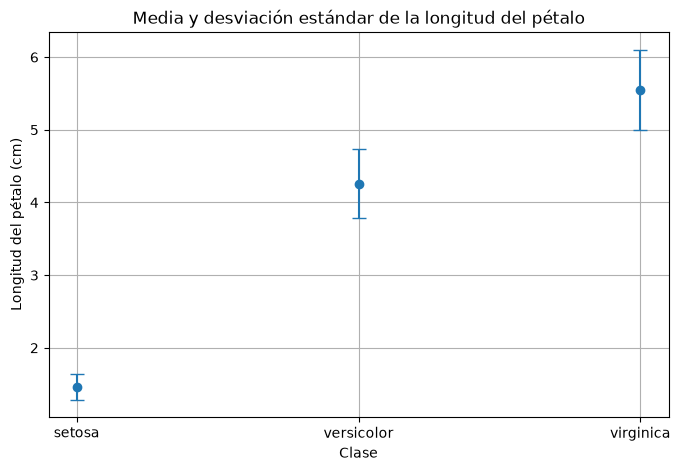

In [16]:
plt.figure(figsize=(8,5))

plt.errorbar(
    media.index,
    media['petal length (cm)'],
    yerr=desviacion['petal length (cm)'],
    fmt='o',
    capsize=5
)

plt.title('Media y desviación estándar de la longitud del pétalo')
plt.xlabel('Clase')
plt.ylabel('Longitud del pétalo (cm)')

plt.grid(True)
plt.show()